In [5]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

In [8]:
import matplotlib
matplotlib.rcParams['figure.figsize'] = (10.0, 10.0)
matplotlib.rcParams['image.cmap'] = 'gray'

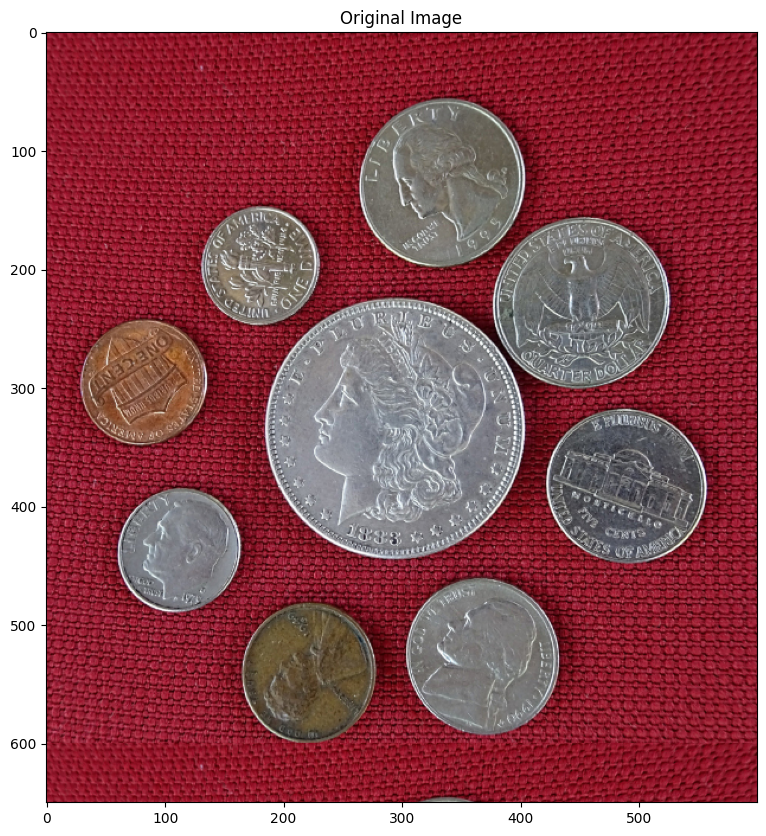

In [9]:
image = cv2.imread('coins.png')
imageCopy = image.copy()
plt.imshow(image[:,:,::-1]);
plt.title("Original Image")
plt.show()

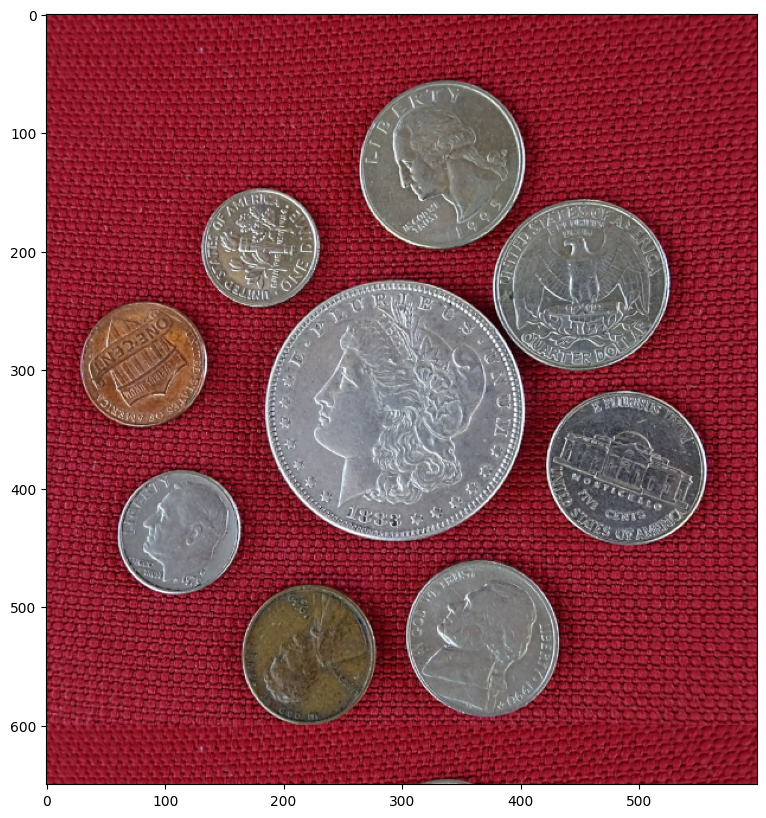

In [10]:
imageCopy1 = image.copy()
plt.imshow(imageCopy1[:,:,::-1]);

In [11]:
imageGray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

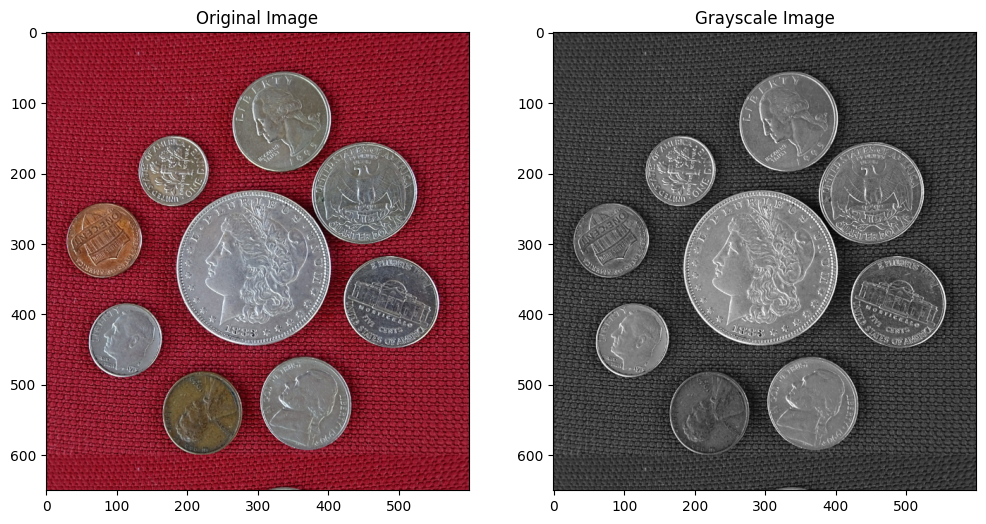

In [12]:
plt.figure(figsize=(12,12))
plt.subplot(121)
plt.imshow(image[:,:,::-1]);
plt.title("Original Image")
plt.subplot(122)
plt.imshow(imageGray);
plt.title("Grayscale Image");

In [13]:
imageB, imageG, imageR = cv2.split(image)

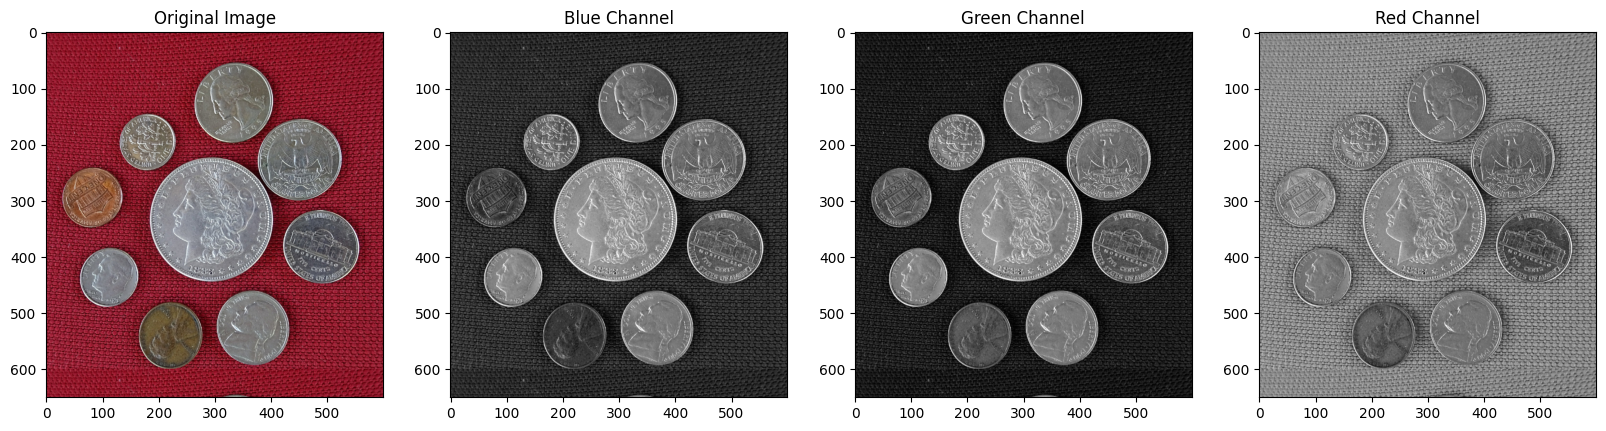

In [14]:
plt.figure(figsize=(20,12))
plt.subplot(141)
plt.imshow(image[:,:,::-1]);
plt.title("Original Image")
plt.subplot(142)
plt.imshow(imageB);
plt.title("Blue Channel")
plt.subplot(143)
plt.imshow(imageG);
plt.title("Green Channel")
plt.subplot(144)
plt.imshow(imageR);
plt.title("Red Channel");

In [16]:
thresh =20
maxValue = 255
th, dst_bin_inv = cv2.threshold(imageG, thresh, maxValue, cv2.THRESH_BINARY_INV)

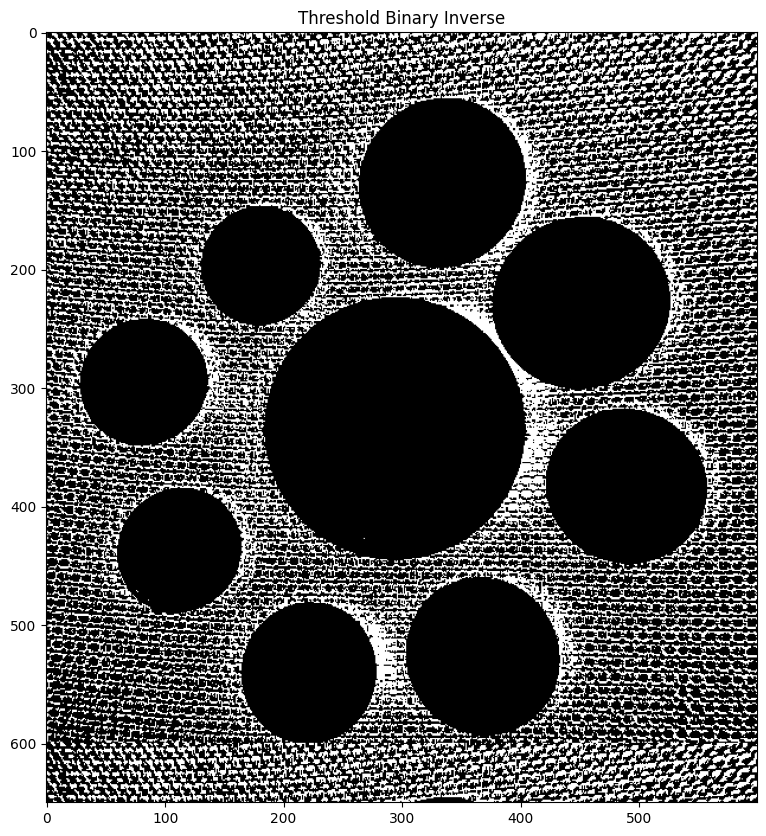

In [17]:
plt.imshow(dst_bin_inv, cmap='gray', vmin=0, vmax=255)
plt.title("Threshold Binary Inverse");

In [18]:
kSize = (5,5)
kernel2 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, kSize)
imageDilated2 = cv2.dilate(dst_bin_inv, kernel2, iterations=2)

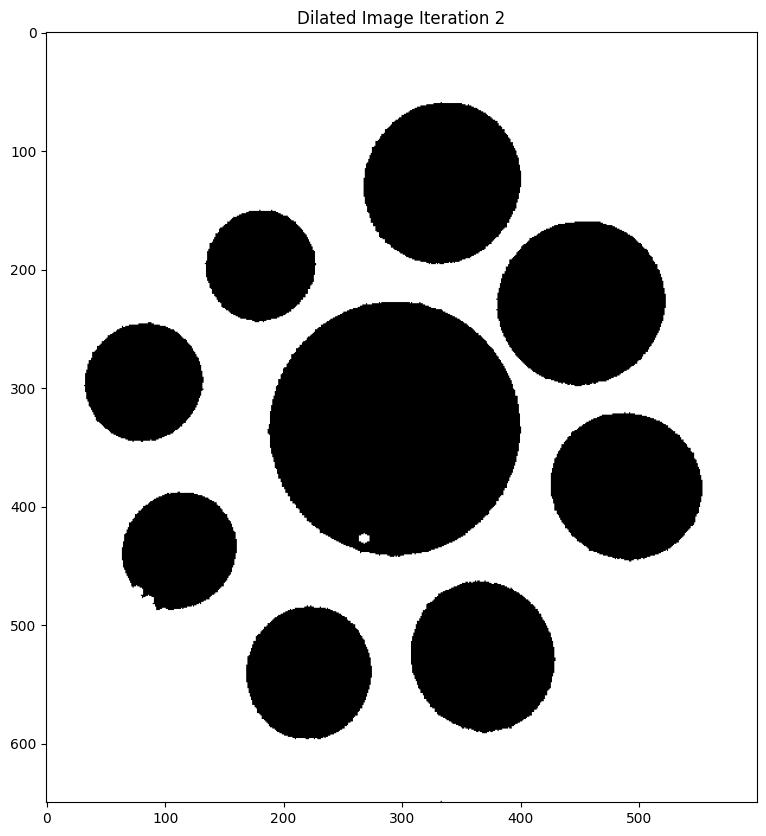

In [19]:
plt.imshow(imageDilated2);plt.title("Dilated Image Iteration 2");

In [21]:
kSize = (11,11)
kernel1 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, kSize)
imageEroded = cv2.erode(imageDilated2, kernel1)

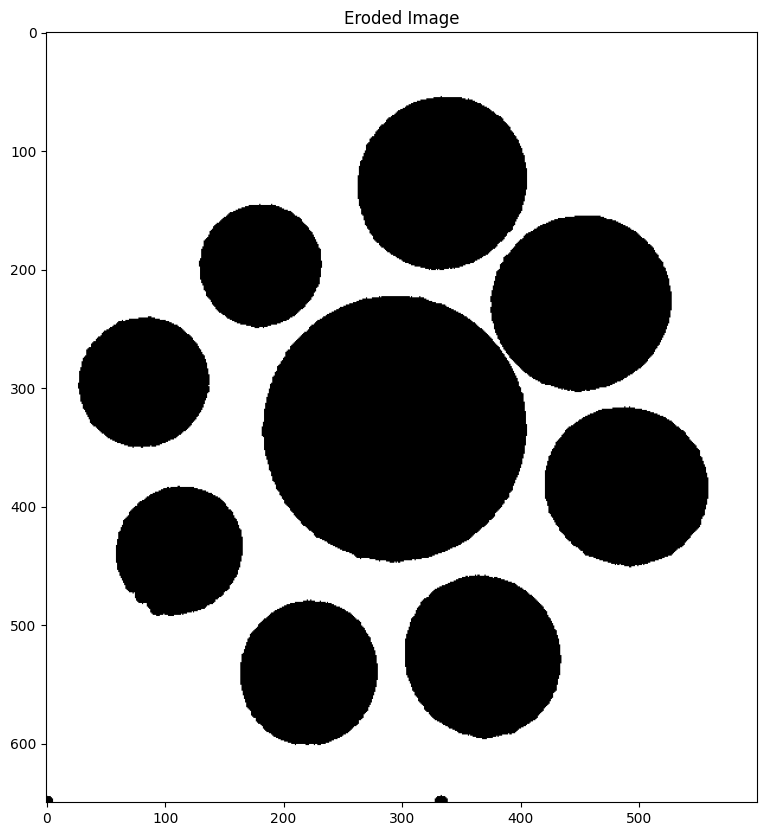

In [22]:
plt.imshow(imageEroded);plt.title("Eroded Image");

In [23]:
params = cv2.SimpleBlobDetector_Params()

params.blobColor = 0

params.minDistBetweenBlobs = 2

# Filter by Area.
params.filterByArea = False

# Filter by Circularity
params.filterByCircularity = True
params.minCircularity = 0.8

# Filter by Convexity
params.filterByConvexity = True
params.minConvexity = 0.8

# Filter by Inertia
params.filterByInertia =True
params.minInertiaRatio = 0.8

In [24]:
detector = cv2.SimpleBlobDetector_create(params)

In [25]:
keypoints = detector.detect(imageEroded)

In [26]:
print(f"Number of coins detected: {len(keypoints)}")

Number of coins detected: 9
